# K-Means Clustering + Interpretation

This Google Colab notebook performs:

- Elbow method
- K-Means with `k = 2`
- K-Means with `k = 3`
- Adjusted Rand Index (ARI)
- Cluster mean profiles
- Lifestyle-based interpretation

The model uses only continuous / ordinal health features:

- `BMI`
- `MentHlth`
- `PhysHlth`
- `GenHlth`

Binary variables are excluded because K-Means relies on Euclidean distance.

In [114]:
import os
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score

print("Libraries loaded successfully")

Libraries loaded successfully


## Upload Dataset
Upload your file: `binary_train.csv`

In [115]:
from google.colab import files

uploaded = files.upload()
file_name = list(uploaded.keys())[0]
print("Uploaded file:", file_name)

Saving multiclass_train.csv to multiclass_train.csv
Uploaded file: multiclass_train.csv


*italicized text*## Load Data

In [116]:
data = pd.read_csv(file_name)

print("Data loaded successfully")
print("Rows:", data.shape[0])
print("Columns:", data.shape[1])

display(data.head())

Data loaded successfully
Rows: 202943
Columns: 22


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,1,1,1,40,1,0,0,0,0,...,1,0,5,18,15,1,0,9,4,3
1,0,0,0,0,25,1,0,0,1,0,...,0,1,3,0,0,0,0,7,6,1
2,0,1,1,1,28,0,0,0,0,1,...,1,1,5,30,30,1,0,9,4,8
3,0,1,0,1,27,0,0,0,1,1,...,1,0,2,0,0,0,0,11,3,6
4,0,1,1,1,25,1,0,0,1,1,...,1,0,2,0,2,0,1,10,6,8


## Select Target and Continuous / Ordinal K-Means Features

In [119]:
target_col = "Diabetes_012" #for multiclass
#target_col = "Diabetes_binary"

kmeans_features = ["BMI", "PhysActivity", "Smoker","PhysHlth"]
kmeans_features = [col for col in kmeans_features if col in data.columns]

print("Features used for K-Means:")
print(kmeans_features)

if target_col not in data.columns:
    raise ValueError(f"Target column '{target_col}' not found in dataset")

if len(kmeans_features) == 0:
    raise ValueError("No K-Means features found in dataset")

Features used for K-Means:
['BMI', 'PhysActivity', 'Smoker', 'PhysHlth']


In [120]:
#ample_size = min(10000, len(data))
#data_sample = data.sample(n=sample_size, random_state=123).reset_index(drop=True)
data_sample = data.copy()

print("Sample size used:", data_sample.shape[0])

Sample size used: 202943


## Scale Selected Features

In [121]:
X = data_sample[kmeans_features].copy()

for col in kmeans_features:
    X[col] = pd.to_numeric(X[col], errors="coerce")

X = X.fillna(X.median(numeric_only=True))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaling completed")
print("Scaled feature matrix shape:", X_scaled.shape)

Scaling completed
Scaled feature matrix shape: (202943, 4)


## Elbow Method

Running K-Means for k = 1
Running K-Means for k = 2
Running K-Means for k = 3
Running K-Means for k = 4
Running K-Means for k = 5
Running K-Means for k = 6
Running K-Means for k = 7
Running K-Means for k = 8
Running K-Means for k = 9
Running K-Means for k = 10


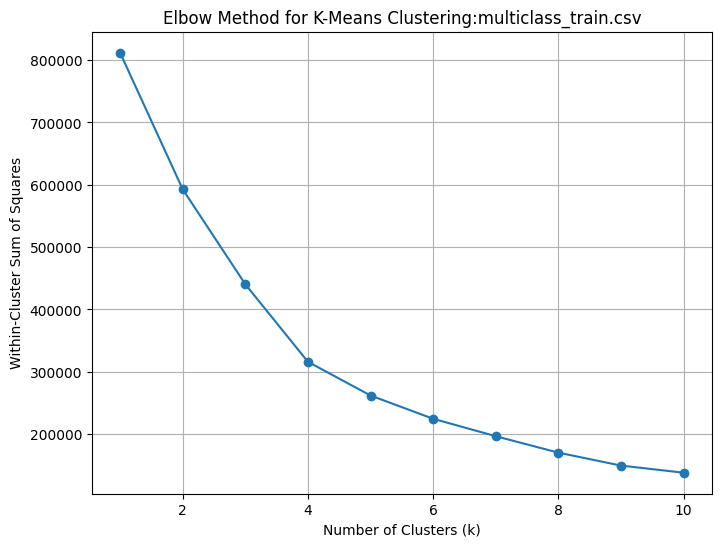

Elbow plot saved at reports/elbow_plot.png


In [122]:
os.makedirs("reports", exist_ok=True)

wss = []
k_values = range(1, 11)

for k in k_values:
    print("Running K-Means for k =", k)
    km = KMeans(n_clusters=k, n_init=10, random_state=123)
    km.fit(X_scaled)
    wss.append(km.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(list(k_values), wss, marker="o")
plt.title(f"Elbow Method for K-Means Clustering:{file_name}")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares")
plt.grid(True)
plt.savefig("reports/elbow_plot.png", dpi=150, bbox_inches="tight")
plt.show()

print("Elbow plot saved at reports/elbow_plot.png")

## K-Means with k = 2 and k = 3

In [123]:
k2_model = KMeans(n_clusters=2, n_init=10, random_state=123)
k2_clusters = k2_model.fit_predict(X_scaled)

k3_model = KMeans(n_clusters=3, n_init=10, random_state=123)
k3_clusters = k3_model.fit_predict(X_scaled)

print(f"K-Means completed for k=2 and k=3 :{file_name}")

K-Means completed for k=2 and k=3 :multiclass_train.csv


## Adjusted Rand Index (ARI)

In [124]:
true_labels = data_sample[target_col]

ari_k2 = adjusted_rand_score(true_labels, k2_clusters)
ari_k3 = adjusted_rand_score(true_labels, k3_clusters)

print(f"Adjusted Rand Index :{file_name}")
print("ARI for k=2:", round(ari_k2, 4))
print("ARI for k=3:", round(ari_k3, 4))

Adjusted Rand Index :multiclass_train.csv
ARI for k=2: 0.0716
ARI for k=3: 0.0239


[link text](https://)## Cluster Mean Profiles

In [125]:
data_k2 = data_sample.copy()
data_k2["cluster"] = k2_clusters

data_k3 = data_sample.copy()
data_k3["cluster"] = k3_clusters

cluster_profile_k2 = (
    data_k2
    .groupby("cluster")
    .agg(
        Count=(target_col, "size"),
        Diabetes_Rate=(target_col, "mean"),
        BMI=("BMI", "mean"),
        MentHlth=("MentHlth", "mean"),
        PhysHlth=("PhysHlth", "mean"),
        GenHlth=("GenHlth", "mean")
    )
    .reset_index()
)

cluster_profile_k3 = (
    data_k3
    .groupby("cluster")
    .agg(
        Count=(target_col, "size"),
        Diabetes_Rate=(target_col, "mean"),
        BMI=("BMI", "mean"),
        MentHlth=("MentHlth", "mean"),
        PhysHlth=("PhysHlth", "mean"),
        GenHlth=("GenHlth", "mean")
    )
    .reset_index()
)

print(f"Cluster Profile: k=2 :{file_name}")
display(cluster_profile_k2)

print(f"Cluster Profile: k=3 :{file_name}")
display(cluster_profile_k3)

cluster_profile_k2.to_csv("reports/kmeans_cluster_profile_k2.csv", index=False)
cluster_profile_k3.to_csv("reports/kmeans_cluster_profile_k3.csv", index=False)

Cluster Profile: k=2 :multiclass_train.csv


,cluster,Count,Diabetes_Rate,BMI,MentHlth,PhysHlth,GenHlth
0,0,49800,0.451667,30.438233,4.861988,7.707771,3.019217
1,1,153143,0.246502,27.716566,2.639957,3.112999,2.346265


Cluster Profile: k=3 :multiclass_train.csv


,cluster,Count,Diabetes_Rate,BMI,MentHlth,PhysHlth,GenHlth
0,0,89165,0.213312,27.724017,2.207750,2.533954,2.221959
1,1,49409,0.451011,30.148293,4.845777,7.649821,3.017831
2,2,64369,0.294225,27.945331,3.264599,3.987494,2.523606


## PCA Visualization

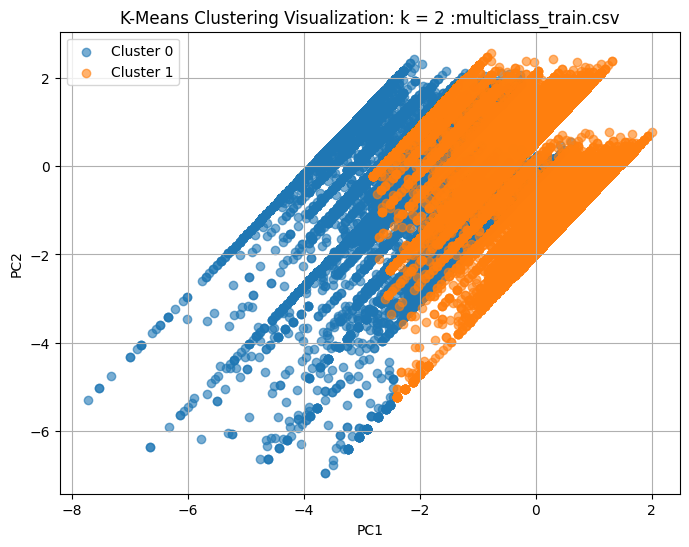

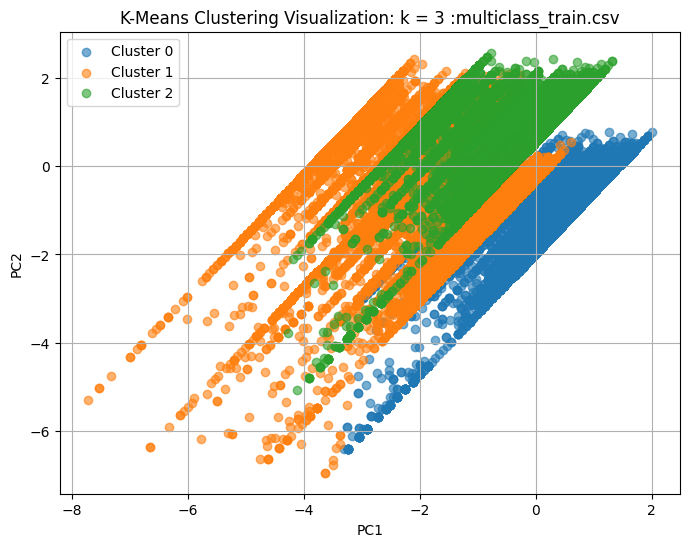

In [126]:
pca = PCA(n_components=2, random_state=123)
pca_scores = pca.fit_transform(X_scaled)

pca_df_k2 = pd.DataFrame({
    "PC1": pca_scores[:, 0],
    "PC2": pca_scores[:, 1],
    "Cluster": k2_clusters.astype(str),
    "Diabetes": true_labels.astype(str)
})

pca_df_k3 = pd.DataFrame({
    "PC1": pca_scores[:, 0],
    "PC2": pca_scores[:, 1],
    "Cluster": k3_clusters.astype(str),
    "Diabetes": true_labels.astype(str)
})

plt.figure(figsize=(8, 6))
for cluster in sorted(pca_df_k2["Cluster"].unique()):
    temp = pca_df_k2[pca_df_k2["Cluster"] == cluster]
    plt.scatter(temp["PC1"], temp["PC2"], label=f"Cluster {cluster}", alpha=0.6)

plt.title(f"K-Means Clustering Visualization: k = 2 :{file_name}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True)
plt.savefig("reports/kmeans_k2_pca_plot.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 6))
for cluster in sorted(pca_df_k3["Cluster"].unique()):
    temp = pca_df_k3[pca_df_k3["Cluster"] == cluster]
    plt.scatter(temp["PC1"], temp["PC2"], label=f"Cluster {cluster}", alpha=0.6)

plt.title(f"K-Means Clustering Visualization: k = 3 :{file_name}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True)
plt.savefig("reports/kmeans_k3_pca_plot.png", dpi=150, bbox_inches="tight")
plt.show()

## Lifestyle Interpretation

In [ ]:
def interpret_clusters(profile_table, k_value):
    print(f"\nLifestyle Interpretation: k = {k_value} : {file_name}")
    print("=" * 60)

    avg_bmi = profile_table["BMI"].mean()
    avg_phys = profile_table["PhysHlth"].mean()
    avg_gen = profile_table["GenHlth"].mean()
    avg_mental = profile_table["MentHlth"].mean()

    interpretations = []

    for _, row in profile_table.iterrows():
        cluster = row["cluster"]

        bmi_desc = "lower BMI" if row["BMI"] < avg_bmi else "higher BMI"
        phys_desc = "better physical health" if row["PhysHlth"] < avg_phys else "poorer physical health"
        gen_desc = "better general health" if row["GenHlth"] < avg_gen else "poorer general health"
        mental_desc = "better mental health" if row["MentHlth"] < avg_mental else "poorer mental health"

        text = (
            f"Cluster {cluster}: Count={int(row['Count'])}, "
            f"Diabetes Rate={row['Diabetes_Rate']:.4f}, "
            f"Avg BMI={row['BMI']:.2f}, "
            f"Avg MentHlth={row['MentHlth']:.2f}, "
            f"Avg PhysHlth={row['PhysHlth']:.2f}, "
            f"Avg GenHlth={row['GenHlth']:.2f}. "
            f"This cluster represents individuals with {bmi_desc}, "
            f"{mental_desc}, {phys_desc}, and {gen_desc}."
        )

        print(text)
        interpretations.append(text)

    return interpretations

interpretation_k2 = interpret_clusters(cluster_profile_k2, 2)
interpretation_k3 = interpret_clusters(cluster_profile_k3, 3)

## Save Final Summary and Download Reports

In [127]:
summary_lines = [
    f"K-Means Clustering Summary :{file_name}",
    "=========================================+++",
    f"Sample size used: {len(data_sample)}",
    f"Features used: {', '.join(kmeans_features)}",
    f"ARI k=2: {ari_k2:.4f}",
    f"ARI k=3: {ari_k3:.4f}",
    "",
    "Interpretation k=2:"
]

summary_lines.extend(interpretation_k2)
summary_lines.append("")
summary_lines.append("Interpretation k=3:")
summary_lines.extend(interpretation_k3)

with open("reports/kmeans_summary.txt", "w") as f:
    f.write("\n".join(summary_lines))

print("\n".join(summary_lines))

shutil.make_archive("kmeans_reports", "zip", "reports")
files.download("kmeans_reports.zip")

K-Means Clustering Summary :multiclass_train.csv
=========================================+++
Sample size used: 202943
Features used: BMI, PhysActivity, Smoker, PhysHlth
ARI k=2: 0.0716
ARI k=3: 0.0239

Interpretation k=2:
Cluster 0.0: Count=49722, Diabetes Rate=0.2119, Avg BMI=30.37, Avg MentHlth=4.84, Avg PhysHlth=7.68, Avg GenHlth=3.02. This cluster represents individuals with higher BMI, poorer mental health, poorer physical health, and poorer general health.
Cluster 1.0: Count=153221, Diabetes Rate=0.1158, Avg BMI=27.74, Avg MentHlth=2.66, Avg PhysHlth=3.12, Avg GenHlth=2.35. This cluster represents individuals with lower BMI, better mental health, better physical health, and better general health.

Interpretation k=3:
Cluster 0.0: Count=89511, Diabetes Rate=0.0997, Avg BMI=27.72, Avg MentHlth=2.23, Avg PhysHlth=2.54, Avg GenHlth=2.22. This cluster represents individuals with lower BMI, better mental health, better physical health, and better general health.
Cluster 1.0: Count=640

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [128]:
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, roc_auc_score
from sklearn.preprocessing import label_binarize
import pandas as pd
import numpy as np

# True labels
y_true = data_sample[target_col].astype(int)

# K-Means predicted cluster labels
y_pred_raw = k3_clusters

# Maps each cluster to the majority true class.
def map_clusters_to_classes(y_true, clusters):
    mapping = {}
    for cluster in np.unique(clusters):
        idx = clusters == cluster
        majority_class = y_true[idx].mode()[0]
        mapping[cluster] = majority_class
    return np.array([mapping[c] for c in clusters]), mapping

y_pred, cluster_mapping = map_clusters_to_classes(y_true, y_pred_raw)

print("Cluster - Class mapping:")
print(cluster_mapping)

# Basic metrics
accuracy = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average="macro")
weighted_f1 = f1_score(y_true, y_pred, average="weighted")

# Per-class precision, recall, F1
classes = [0, 1, 2]

precision, recall, f1, support = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=classes,
    zero_division=0
)

# Calculate AUC calculation using negative distance to cluster centers as score.

distances = k3_model.transform(X_scaled)
scores = -distances

# Reorder scores according to mapped class
score_by_class = np.zeros((len(y_true), len(classes)))

for cluster_id, class_id in cluster_mapping.items():
    if class_id in classes:
        class_index = classes.index(class_id)
        score_by_class[:, class_index] = scores[:, cluster_id]

# Binarize true labels for OvR AUC
y_true_bin = label_binarize(y_true, classes=classes)

class_auc = {}

for i, cls in enumerate(classes):
    y_true_cls = y_true_bin[:, i]
    y_score_cls = score_by_class[:, i]

    # Check if both classes exist
    if len(np.unique(y_true_cls)) < 2:
        print(f"Skipping AUC for class {cls} (only one class present)")
        class_auc[cls] = np.nan
    else:
        class_auc[cls] = roc_auc_score(y_true_cls, y_score_cls)

avg_auc = np.nanmean(list(class_auc.values()))

metrics_table = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Macro F1",
        "Weighted F1",
        "Avg AUC"
    ],
    "Value": [
        accuracy,
        macro_f1,
        weighted_f1,
        avg_auc
    ]
})

display(metrics_table)

# Save to CSV
metrics_table.to_csv("reports/kmeans_multiclass_metrics.csv", index=False)

Cluster - Class mapping:
{np.int32(0): np.int64(0), np.int32(1): np.int64(0), np.int32(2): np.int64(0)}


,Metric,Value
0,Accuracy,0.842478
1,Macro F1,0.304835
2,Weighted F1,0.770451
3,Avg AUC,0.534484


In [ ]:
print("############################# END#########################")